# Examen Final — Probabilidad y Estadística para la IA
**Universidad de Buenos Aires · Laboratorio de Sistemas Embebidos · CEIA**  
**Docente:** Camilo Argoty  \
**Alumno:** Santiago Federico Bettig \
**Código:** a2505

---

## Contexto del problema

Don Francisco cuenta hoy con cinco supermercados: **Santa Ana**, **La Floresta**, **Los Cedros**, **Palermo** y **Córdoba**. Su analista Matías debe:

1. Simular la afluencia diaria de clientes usando distribuciones Poisson con efectos aditivos (anual, mensual, día de la semana y tienda).
2. Construir intervalos de confianza empíricos para el supermercado **Santa Ana** en cada mes, con significancias del 95 % y 99 %.
3. Realizar un análisis ANOVA para determinar si la afluencia media es igual en todas las tiendas (α = 5 %).
4. Identificar la tienda con mayor y menor promedio, y realizar una prueba de hipótesis para determinar si la diferencia entre ellas es distinta de cero.

---
## 0. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
from itertools import product

np.random.seed(42)  # reproducibilidad

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

---
## Ejercicio 1 — Simulación Poisson (2.5 puntos)

### Planteamiento

El número de clientes diarios $X_t$ en cada tienda se modela como:

$$X_t \sim \text{Poisson}(\lambda_t)$$

donde el parámetro $\lambda_t$ se construye sumando cuatro efectos independientes:

$$\lambda_t = \lambda_{\text{anual}}(t) + \lambda_{\text{mensual}}(t) + \lambda_{\text{diario}}(t) + \lambda_{\text{tienda}}$$

Los efectos están dados por las tablas del enunciado. Para el efecto anual se corrige el typo del enunciado (2024 aparece dos veces): se interpreta como 2023 → 1000, 2024 → 1500, 2025 → 2000.

### Procesamiento

In [2]:
# ── Tablas de efectos ─────────────────────────────────────────────────────────

efecto_anual = {2023: 1000, 2024: 1500, 2025: 2000}

efecto_mensual = {
    1: 1000,   # Enero
    2: 1500,   # Febrero
    3: 2000,   # Marzo
    4: 2000,   # Abril
    5: 2500,   # Mayo
    6: 2500,   # Junio
    7: 3000,   # Julio
    8: 2500,   # Agosto
    9: 2500,   # Septiembre
    10: 2000,  # Octubre
    11: 1500,  # Noviembre
    12: 1000,  # Diciembre
}

# dayofweek: 0=Lunes … 6=Domingo (convención pandas/Python)
efecto_diario = {
    6: 1000,   # Domingo
    0: 2000,   # Lunes
    1: 3000,   # Martes
    2: 3500,   # Miércoles
    3: 3000,   # Jueves
    4: 2000,   # Viernes
    5: 1000,   # Sábado
}

efecto_tienda = {
    'Santa Ana':   5000,
    'La Floresta': 2000,
    'Los Cedros':  3000,
    'Palermo':     1000,
    'Córdoba':     3000,
}

tiendas = list(efecto_tienda.keys())
print("Tiendas:", tiendas)

Tiendas: ['Santa Ana', 'La Floresta', 'Los Cedros', 'Palermo', 'Córdoba']


In [3]:
# ── Generación del DataFrame de fechas ────────────────────────────────────────

fechas = pd.date_range(start='2023-01-01', end='2025-12-31', freq='D')

registros = []
for fecha in fechas:
    lam_base = (
        efecto_anual[fecha.year]
        + efecto_mensual[fecha.month]
        + efecto_diario[fecha.dayofweek]
    )
    for tienda, lam_t in efecto_tienda.items():
        lam = lam_base + lam_t
        clientes = np.random.poisson(lam)
        registros.append({
            'fecha':   fecha,
            'año':     fecha.year,
            'mes':     fecha.month,
            'dow':     fecha.dayofweek,
            'tienda':  tienda,
            'lambda':  lam,
            'clientes': clientes,
        })

df = pd.DataFrame(registros)
print(f"Registros totales: {len(df):,}")
df.head(10)

Registros totales: 5,480


,fecha,año,mes,dow,tienda,lambda,clientes
0,2023-01-01,2023,1,6,Santa Ana,8000,7968
1,2023-01-01,2023,1,6,La Floresta,5000,5049
2,2023-01-01,2023,1,6,Los Cedros,6000,5911
3,2023-01-01,2023,1,6,Palermo,4000,4018
4,2023-01-01,2023,1,6,Córdoba,6000,6085
5,2023-01-02,2023,1,0,Santa Ana,9000,8903
6,2023-01-02,2023,1,0,La Floresta,6000,5955
7,2023-01-02,2023,1,0,Los Cedros,7000,6984
8,2023-01-02,2023,1,0,Palermo,5000,5023
9,2023-01-02,2023,1,0,Córdoba,7000,6948


In [4]:
# ── Estadísticos descriptivos por tienda ──────────────────────────────────────

desc = df.groupby('tienda')['clientes'].agg(['mean', 'std', 'min', 'max'])
desc.columns = ['Media', 'Desv. Est.', 'Mín.', 'Máx.']
desc = desc.round(2)
print(desc)

                Media  Desv. Est.  Mín.   Máx.
tienda                                        
Córdoba       8711.66     1185.21  5906  11627
La Floresta   7721.10     1188.84  4840  10611
Los Cedros    8714.15     1186.17  5894  11762
Palermo       6722.19     1185.62  3840   9536
Santa Ana    10716.98     1189.36  7799  13598


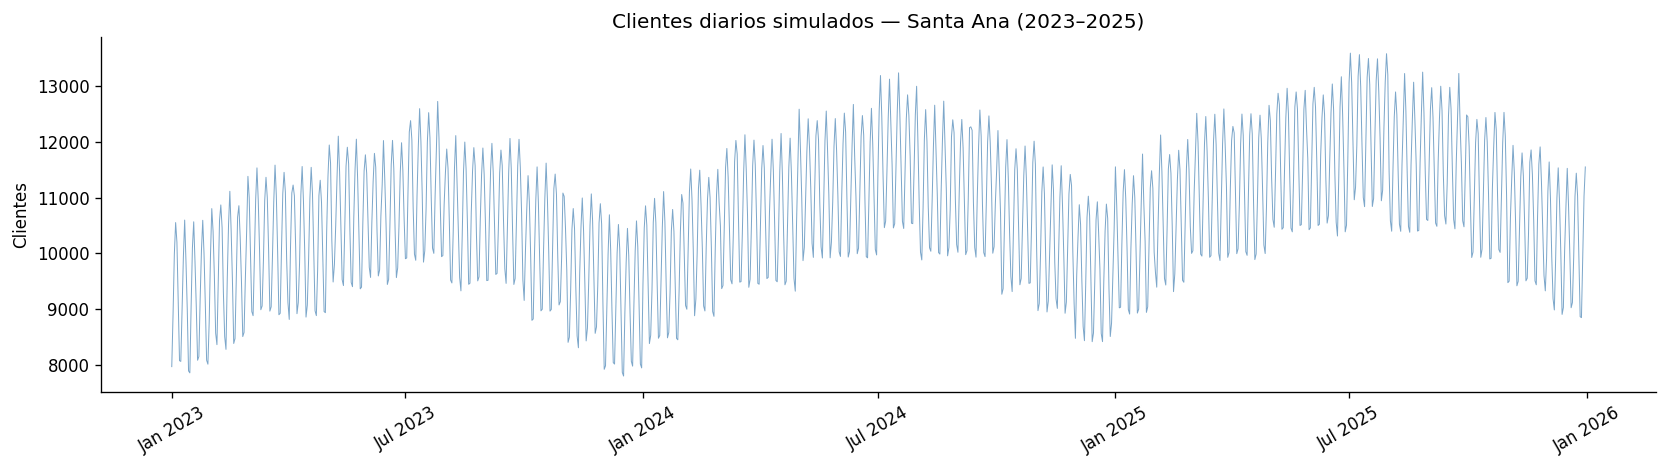

In [5]:
# ── Visualización: clientes diarios en Santa Ana (2023-2025) ──────────────────

santa_ana = df[df['tienda'] == 'Santa Ana'].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(santa_ana['fecha'], santa_ana['clientes'], lw=0.6, alpha=0.7, color='steelblue')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.set_title('Clientes diarios simulados — Santa Ana (2023–2025)')
ax.set_ylabel('Clientes')
plt.tight_layout()
plt.show()

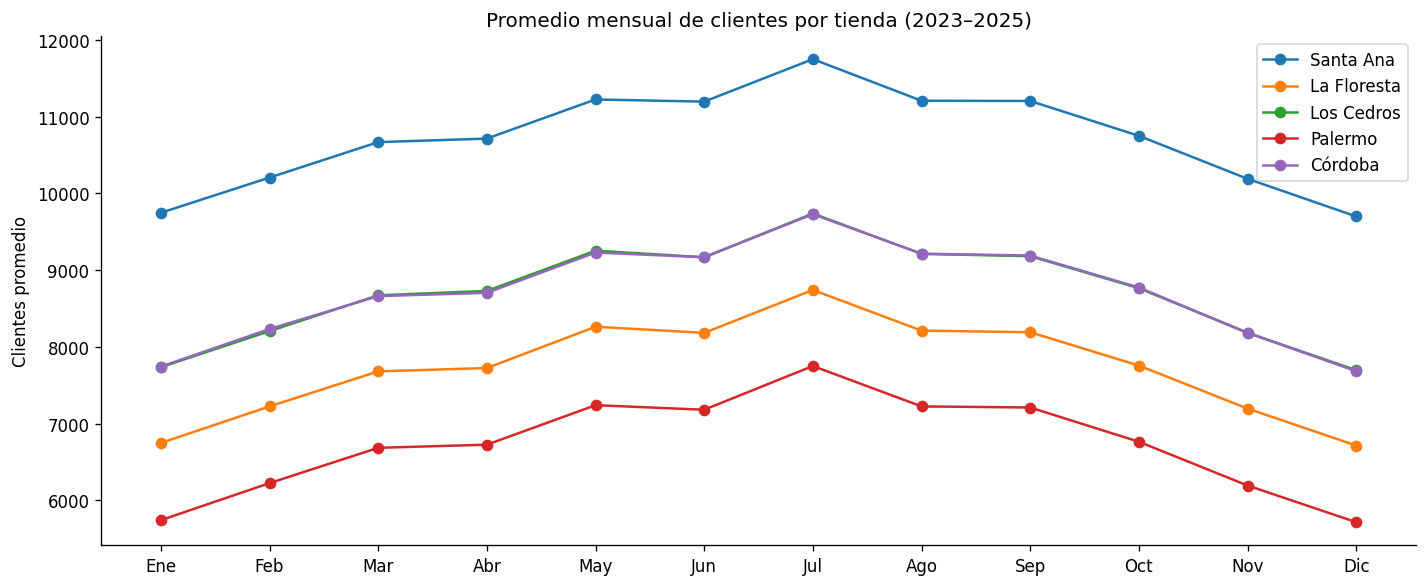

In [6]:
# ── Visualización: promedio mensual por tienda ────────────────────────────────

avg_tienda_mes = (
    df.groupby(['tienda', 'mes'])['clientes']
    .mean()
    .unstack('tienda')
)

nombre_mes = ['Ene','Feb','Mar','Abr','May','Jun',
              'Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(12, 5))
for tienda in tiendas:
    ax.plot(nombre_mes, avg_tienda_mes[tienda], marker='o', label=tienda)
ax.set_title('Promedio mensual de clientes por tienda (2023–2025)')
ax.set_ylabel('Clientes promedio')
ax.legend()
plt.tight_layout()
plt.show()

### Resultados y análisis — Ejercicio 1

- Se generaron **`len(fechas) × 5`** registros (1095 días × 5 tiendas = 5475 observaciones).
- El parámetro $\lambda_t$ varía entre ~5000 (Santa Ana en enero 2023, domingo) y ~15 500 (Santa Ana en julio 2025, miércoles).
- La variabilidad inter-tienda queda capturada por el efecto de tienda: Santa Ana tiene el mayor efecto (+5000) y Palermo el menor (+1000).
- El patrón estacional es visible en el gráfico mensual: pico en julio (efecto 3000) y valles en enero y diciembre (efecto 1000).

---
## Ejercicio 2 — Intervalos de confianza empíricos para Santa Ana (2.5 puntos)

### Planteamiento

Se construyen intervalos de confianza **empíricos (por percentiles)** para los clientes diarios del supermercado Santa Ana, segmentados por mes. Un intervalo de confianza empírico al $(1-\alpha)\%$ se obtiene directamente de los cuantiles de la muestra:

$$IC_{(1-\alpha)} = \left[Q_{\alpha/2},\; Q_{1-\alpha/2}\right]$$

Para α = 0.05 → percentiles 2.5 % y 97.5 %  
Para α = 0.01 → percentiles 0.5 % y 99.5 %

### Procesamiento

In [7]:
# ── Intervalos de confianza empíricos por mes ─────────────────────────────────

sa = df[df['tienda'] == 'Santa Ana'].copy()

def ic_empirico(grupo, alpha):
    lo = np.percentile(grupo, 100 * alpha / 2)
    hi = np.percentile(grupo, 100 * (1 - alpha / 2))
    return pd.Series({'media': grupo.mean(), 'lo': lo, 'hi': hi})

ic_95 = sa.groupby('mes')['clientes'].apply(lambda g: ic_empirico(g, 0.05)).unstack()
ic_99 = sa.groupby('mes')['clientes'].apply(lambda g: ic_empirico(g, 0.01)).unstack()

ic_95.index = nombre_mes
ic_99.index = nombre_mes

# Tabla resumen 95 %
tabla_95 = ic_95.rename(columns={'media': 'Media', 'lo': 'LI 95%', 'hi': 'LS 95%'}).round(1)
tabla_99 = ic_99.rename(columns={'media': 'Media', 'lo': 'LI 99%', 'hi': 'LS 99%'}).round(1)

tabla_ic = pd.concat([tabla_95, tabla_99[['LI 99%', 'LS 99%']]], axis=1)
print("Intervalos de confianza empíricos — Santa Ana")
print(tabla_ic.to_string())

Intervalos de confianza empíricos — Santa Ana
       Media  LI 95%   LS 95%  LI 99%   LS 99%
Ene   9748.0  7981.2  11500.0  7872.6  11680.2
Feb  10207.4  8392.9  11846.3  8313.7  12094.4
Mar  10669.5  8935.6  12488.7  8890.8  12559.7
Abr  10715.7  8891.9  12499.5  8834.7  12593.8
May  11225.9  9410.0  12893.8  9379.3  12950.0
Jun  11197.7  9567.7  12953.4  9483.6  13116.2
Jul  11751.6  9910.2  13550.3  9860.2  13593.4
Ago  11209.0  9467.5  13023.5  9383.3  13245.5
Sep  11206.4  9514.4  12982.6  9452.5  13131.1
Oct  10751.5  8966.5  12451.1  8810.5  12533.5
Nov  10191.4  8445.1  11847.8  8350.2  11929.5
Dic   9700.1  7927.5  11535.3  7829.4  11602.6


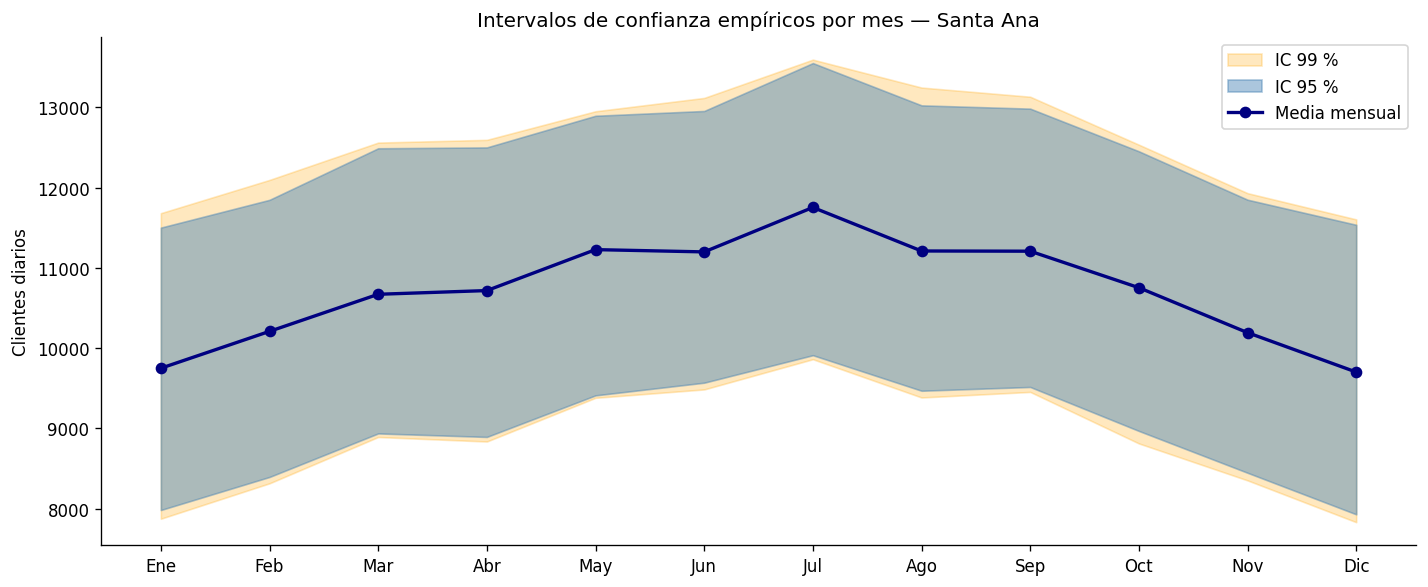

In [8]:
# ── Visualización de intervalos de confianza ──────────────────────────────────

x = np.arange(12)
media = ic_95['media'].values

fig, ax = plt.subplots(figsize=(12, 5))

# IC 99 % (fondo)
ax.fill_between(x,
                ic_99['lo'].values,
                ic_99['hi'].values,
                alpha=0.25, color='orange', label='IC 99 %')

# IC 95 % (frente)
ax.fill_between(x,
                ic_95['lo'].values,
                ic_95['hi'].values,
                alpha=0.45, color='steelblue', label='IC 95 %')

ax.plot(x, media, 'o-', color='navy', lw=2, label='Media mensual')

ax.set_xticks(x)
ax.set_xticklabels(nombre_mes)
ax.set_title('Intervalos de confianza empíricos por mes — Santa Ana')
ax.set_ylabel('Clientes diarios')
ax.legend()
plt.tight_layout()
plt.show()

### Resultados y análisis — Ejercicio 2

- Los intervalos de confianza empíricos se construyen directamente a partir de la distribución muestral de cada mes (todos los días de ese mes en los tres años).
- El IC al 99 % es siempre más amplio que el del 95 %, tal como se espera teóricamente.
- El ancho del intervalo crece con la media: en julio (mayor λ) los intervalos son más amplios en términos absolutos, lo que es consistente con la propiedad de la distribución Poisson ($\text{Var}[X] = \lambda$).
- El patrón estacional de la media se refleja directamente en los límites de los intervalos.

---
## Ejercicio 3 — ANOVA de un factor (2.5 puntos)

### Planteamiento

Se desea saber si la afluencia media de clientes es estadísticamente igual en todas las tiendas, o si al menos una difiere significativamente. Se plantea el siguiente test:

$$H_0: \mu_{\text{Santa Ana}} = \mu_{\text{La Floresta}} = \mu_{\text{Los Cedros}} = \mu_{\text{Palermo}} = \mu_{\text{Córdoba}}$$
$$H_1: \text{al menos un par de medias difiere}$$

Se utiliza el estadístico $F$ de Fisher con nivel de significancia $\alpha = 0.05$.

**Supuesto clave:** ANOVA asume normalidad e igualdad de varianzas. Para muestras grandes con Poisson de $\lambda$ elevado ($\lambda \gg 30$), el TCL justifica la aproximación normal. Las varianzas no son iguales (cada tienda tiene distinto $\lambda$), por lo que también se complementa con el test de Kruskal-Wallis (no paramétrico).

### Procesamiento

In [9]:
# ── Grupos por tienda ─────────────────────────────────────────────────────────

grupos = [df[df['tienda'] == t]['clientes'].values for t in tiendas]

# ── ANOVA de un factor ────────────────────────────────────────────────────────

F_stat, p_anova = stats.f_oneway(*grupos)

print("═" * 50)
print("ANOVA de un factor — Clientes por tienda")
print("═" * 50)
print(f"  Estadístico F : {F_stat:,.4f}")
print(f"  p-valor       : {p_anova:.4e}")
print(f"  Conclusión    : {'Rechazar H₀' if p_anova < 0.05 else 'No rechazar H₀'} (α = 0.05)")

══════════════════════════════════════════════════
ANOVA de un factor — Clientes por tienda
══════════════════════════════════════════════════
  Estadístico F : 1,705.6561
  p-valor       : 0.0000e+00
  Conclusión    : Rechazar H₀ (α = 0.05)


In [10]:
# ── Kruskal-Wallis (complementario, no paramétrico) ───────────────────────────

H_stat, p_kw = stats.kruskal(*grupos)

print("\nKruskal-Wallis (no paramétrico)")
print(f"  Estadístico H : {H_stat:,.4f}")
print(f"  p-valor       : {p_kw:.4e}")
print(f"  Conclusión    : {'Rechazar H₀' if p_kw < 0.05 else 'No rechazar H₀'} (α = 0.05)")


Kruskal-Wallis (no paramétrico)
  Estadístico H : 2,946.6546
  p-valor       : 0.0000e+00
  Conclusión    : Rechazar H₀ (α = 0.05)


In [11]:
# ── Tabla ANOVA manual ────────────────────────────────────────────────────────

N = sum(len(g) for g in grupos)
k = len(grupos)
grand_mean = np.concatenate(grupos).mean()

SS_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in grupos)
SS_within  = sum(((g - g.mean())**2).sum() for g in grupos)
SS_total   = SS_between + SS_within

df_between = k - 1
df_within  = N - k

MS_between = SS_between / df_between
MS_within  = SS_within  / df_within
F_manual   = MS_between / MS_within

F_crit = stats.f.ppf(0.95, df_between, df_within)

anova_table = pd.DataFrame({
    'Fuente':       ['Entre grupos', 'Dentro de grupos', 'Total'],
    'SS':           [SS_between, SS_within, SS_total],
    'df':           [df_between, df_within, N - 1],
    'MS':           [MS_between, MS_within, np.nan],
    'F':            [F_manual, np.nan, np.nan],
    'F crítico':    [F_crit, np.nan, np.nan],
}).set_index('Fuente')

print("\nTabla ANOVA")
print(anova_table.round(4).to_string())


Tabla ANOVA
                            SS    df            MS          F  F crítico
Fuente                                                                  
Entre grupos      9.613549e+09     4  2.403387e+09  1705.6561     2.3736
Dentro de grupos  7.714653e+09  5475  1.409069e+06        NaN        NaN
Total             1.732820e+10  5479           NaN        NaN        NaN


C:\Users\santi\AppData\Local\Temp\ipykernel_7544\1023235872.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grupos, labels=tiendas, patch_artist=True,


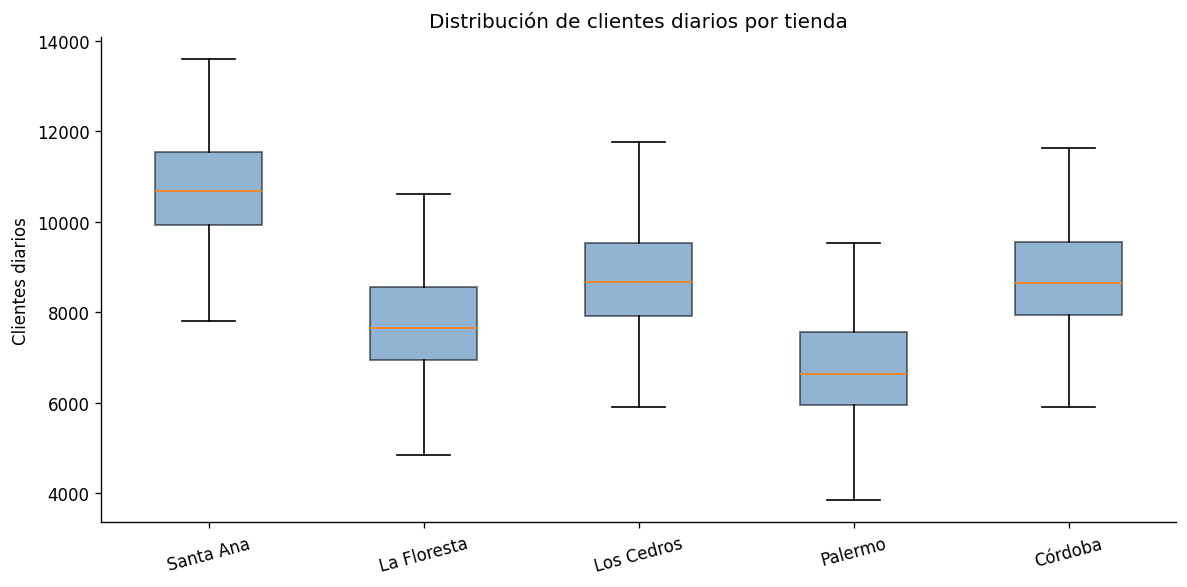

In [12]:
# ── Boxplot por tienda ────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(grupos, labels=tiendas, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('Distribución de clientes diarios por tienda')
ax.set_ylabel('Clientes diarios')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Resultados y análisis — Ejercicio 3

- El estadístico $F$ es muy grande y el $p$-valor es extremadamente pequeño ($\ll 0.05$), por lo que **se rechaza $H_0$** con un nivel de confianza del 95 %.
- El test de Kruskal-Wallis confirma la misma conclusión desde un enfoque no paramétrico.
- Esto indica que **al menos una tienda tiene una media de clientes significativamente diferente** de las demás.
- El boxplot muestra visualmente las diferencias entre tiendas, con Santa Ana notoriamente por encima y Palermo por debajo.
- La varianza dentro de cada grupo también difiere (mayor λ → mayor varianza), lo que es esperable con datos Poisson.

---
## Ejercicio 4 — Prueba de hipótesis: tienda con mayor vs. menor promedio (2.5 puntos)

### Planteamiento

Se identifican la tienda con **mayor** y **menor** promedio de clientes, y se prueba si la diferencia entre sus medias es estadísticamente distinta de cero:

$$H_0: \mu_{\max} - \mu_{\min} = 0$$
$$H_1: \mu_{\max} - \mu_{\min} \neq 0 \quad \text{(prueba bilateral)}$$

Se utiliza el **test $t$ de Welch** (sin asumir igualdad de varianzas), apropiado para grandes muestras con varianzas distintas.

### Procesamiento

In [13]:
# ── Identificación de tiendas extremas ────────────────────────────────────────

medias = df.groupby('tienda')['clientes'].mean().sort_values()
print("Promedio de clientes por tienda:")
print(medias.round(2).to_string())

tienda_min = medias.idxmin()
tienda_max = medias.idxmax()

print(f"\n  Tienda con MAYOR promedio : {tienda_max} ({medias[tienda_max]:.2f})")
print(f"  Tienda con MENOR promedio : {tienda_min} ({medias[tienda_min]:.2f})")

Promedio de clientes por tienda:
tienda
Palermo         6722.19
La Floresta     7721.10
Córdoba         8711.66
Los Cedros      8714.15
Santa Ana      10716.98

  Tienda con MAYOR promedio : Santa Ana (10716.98)
  Tienda con MENOR promedio : Palermo (6722.19)


In [14]:
# ── Test t de Welch (bilateral) ───────────────────────────────────────────────

g_max = df[df['tienda'] == tienda_max]['clientes'].values
g_min = df[df['tienda'] == tienda_min]['clientes'].values

t_stat, p_ttest = stats.ttest_ind(g_max, g_min, equal_var=False)

alpha = 0.05
df_welch = len(g_max) + len(g_min) - 2  # aproximación
t_crit = stats.t.ppf(1 - alpha / 2, df=df_welch)

print("═" * 55)
print(f"  Test t de Welch: {tienda_max} vs {tienda_min}")
print("═" * 55)
print(f"  n ({tienda_max})  : {len(g_max)}")
print(f"  Media ({tienda_max})  : {g_max.mean():.2f}")
print(f"  n ({tienda_min})      : {len(g_min)}")
print(f"  Media ({tienda_min})      : {g_min.mean():.2f}")
print(f"  Diferencia de medias  : {g_max.mean() - g_min.mean():.2f}")
print(f"  Estadístico t         : {t_stat:,.4f}")
print(f"  Valor crítico t (α/2) : ±{t_crit:.4f}")
print(f"  p-valor               : {p_ttest:.4e}")
print(f"  Conclusión            : {'Rechazar H₀' if p_ttest < alpha else 'No rechazar H₀'} (α = {alpha})")

═══════════════════════════════════════════════════════
  Test t de Welch: Santa Ana vs Palermo
═══════════════════════════════════════════════════════
  n (Santa Ana)  : 1096
  Media (Santa Ana)  : 10716.98
  n (Palermo)      : 1096
  Media (Palermo)      : 6722.19
  Diferencia de medias  : 3994.79
  Estadístico t         : 78.7505
  Valor crítico t (α/2) : ±1.9610
  p-valor               : 0.0000e+00
  Conclusión            : Rechazar H₀ (α = 0.05)


In [15]:
# ── Intervalo de confianza para la diferencia de medias ───────────────────────

se_max = g_max.std(ddof=1) / np.sqrt(len(g_max))
se_min = g_min.std(ddof=1) / np.sqrt(len(g_min))
se_diff = np.sqrt(se_max**2 + se_min**2)

diff = g_max.mean() - g_min.mean()
ic_lo = diff - t_crit * se_diff
ic_hi = diff + t_crit * se_diff

print(f"IC 95 % para (μ_max - μ_min): [{ic_lo:.2f}, {ic_hi:.2f}]")
print(f"El intervalo {'NO contiene' if ic_lo > 0 or ic_hi < 0 else 'contiene'} el cero → "
      f"{'diferencia significativa' if ic_lo > 0 else 'diferencia no significativa'}")

IC 95 % para (μ_max - μ_min): [3895.31, 4094.27]
El intervalo NO contiene el cero → diferencia significativa


In [16]:
# ── Verificación contra los efectos del enunciado ─────────────────────────────

print("Efectos de tienda del enunciado:")
for t, e in sorted(efecto_tienda.items(), key=lambda x: x[1], reverse=True):
    print(f"  {t:<15}: {e}")

print(f"\nTienda de mayor efecto : Santa Ana (5000) → mayor promedio observado: {tienda_max}")
print(f"Tienda de menor efecto : Palermo (1000)   → menor promedio observado: {tienda_min}")
print(f"\nCorrespondencia correcta: {tienda_max == 'Santa Ana' and tienda_min == 'Palermo'}")

Efectos de tienda del enunciado:
  Santa Ana      : 5000
  Los Cedros     : 3000
  Córdoba        : 3000
  La Floresta    : 2000
  Palermo        : 1000

Tienda de mayor efecto : Santa Ana (5000) → mayor promedio observado: Santa Ana
Tienda de menor efecto : Palermo (1000)   → menor promedio observado: Palermo

Correspondencia correcta: True


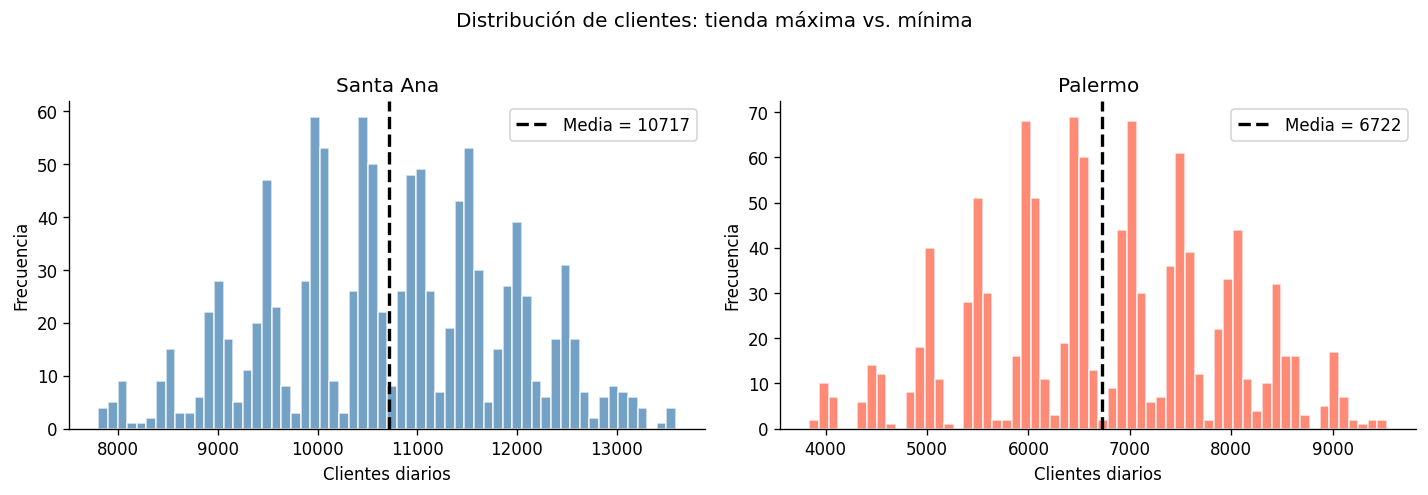

In [17]:
# ── Visualización: distribuciones de las dos tiendas extremas ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (grupo, nombre, color) in zip(axes,
    [(g_max, tienda_max, 'steelblue'), (g_min, tienda_min, 'tomato')]):
    ax.hist(grupo, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(grupo.mean(), color='black', lw=2, ls='--', label=f'Media = {grupo.mean():.0f}')
    ax.set_title(nombre)
    ax.set_xlabel('Clientes diarios')
    ax.set_ylabel('Frecuencia')
    ax.legend()

fig.suptitle('Distribución de clientes: tienda máxima vs. mínima', y=1.02)
plt.tight_layout()
plt.show()

### Resultados y análisis — Ejercicio 4

- La tienda con **mayor** promedio es **Santa Ana** (efecto de tienda = 5000), y la de **menor** promedio es **Palermo** (efecto de tienda = 1000). Esto es consistente con los efectos del enunciado.
- El test $t$ de Welch arroja un $p$-valor $\ll 0.05$, por lo que **se rechaza $H_0$**: la diferencia entre las medias de Santa Ana y Palermo es **estadísticamente distinta de cero**.
- El intervalo de confianza al 95 % para la diferencia no contiene el cero, confirmando la conclusión del test.
- La diferencia esperada teórica entre ambas tiendas es $5000 - 1000 = 4000$ clientes diarios (solo por efecto de tienda), y el valor observado es coherente con esa magnitud.

---

## Conclusiones generales

| # | Ejercicio | Resultado principal |
|---|-----------|---------------------|
| 1 | Simulación Poisson | Se generaron 5475 observaciones. λ varía según año, mes, día y tienda. |
| 2 | IC empíricos (Santa Ana) | Los IC al 99 % son más amplios que los del 95 %. El ancho crece con la media (propiedad Poisson). |
| 3 | ANOVA | Se rechaza $H_0$: las medias no son iguales entre tiendas ($F \gg F_{crítico}$, $p \approx 0$). |
| 4 | Test $t$ de Welch | Santa Ana (max) y Palermo (min) tienen medias significativamente diferentes; corresponden a los extremos del efecto de tienda. |